# The Fourth Circle: Neural Networks, Part Two 
## Convolutional Neural Networks X

<br/>
Jiří Fejlek

2026-05-31
<br/>

We are nearing the end of our series on convolutional neural networks (CNNs). In this project, we will introduce ConvMixer from 2022 [[1](#1)], a CNN that is heavily inspired by Vision Transformers (ViT) [[2](#2)], which became, for many vision tasks, the go-to architecture after the revolution in machine learning caused by introduction of self-attention mechanism [[3](#3)]. 

## Table of Contents

- [ConvMixer](#convmixer)
    - [Training ConvMixer on Fashion-MNIST and CIFAR-10](#training)
    - [Transfer Learning ConvMixer from ImageNet to CIFAR-10](#transfer)
- [References](#references)

## ConvMixer <a class="anchor" id="convmixer"></a>

We first repeat the common functions we use for training almost every CNN in this chapter.

In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

import torchvision
import torch

from torch import nn
from torch.utils.data import DataLoader
from torchvision.ops import StochasticDepth

np.set_printoptions(legacy='1.25')

In [2]:
cuda_device = torch.device('cuda')
torch.cuda.get_device_name(cuda_device)

'NVIDIA GeForce RTX 4070 Ti'

In [3]:
def layer_summary(nn_model, X_shape):
    X = torch.randn(*X_shape)
    for layer in nn_model.net_stack:
        X = layer(X)
        print(layer.__class__.__name__, 'output shape:\t', X.shape)

In [4]:
def init_weights_he(model):
    if isinstance(model, nn.Linear):
        nn.init.kaiming_normal_(model.weight, nonlinearity = 'relu') 
        nn.init.constant_(model.bias, 0) 
    if isinstance(model, nn.Conv2d):
        nn.init.kaiming_normal_(model.weight, nonlinearity = 'relu') 
        nn.init.constant_(model.bias, 0)

In [5]:
def train_test_loop_cuda(train_data_loader, test_data_loader, model, loss_fn, optimizer, scheduler):
    
    softmax = torch.nn.Softmax(dim = 1)
    model.train()

    loss_sum_train  = 0
    accu_sum_train = 0
    size_train = 0

    
    for batch, (X, y) in enumerate(train_data_loader):

        X = X.to(cuda_device)
        y = y.to(cuda_device)

        optimizer.zero_grad() # zero out the gradients
        
        pred_logits = model(X) # forward pass
        loss = loss_fn(pred_logits, y) # loss evaluation 

        # Backpropagation
        loss.backward() # gradient evaluation
        optimizer.step() # SGD step
        

        # compute prediction epoch loss and accuracy
        with torch.no_grad(): # we do not need to compute the gradients
            loss_sum_train = loss_sum_train + loss*len(X)
            size_train = size_train + len(X)
            accu_sum_train = accu_sum_train + ((softmax(pred_logits).argmax(dim = 1)-y).abs() == 0).long().sum()

    # evaluate performance on the test set
    with torch.no_grad(): 
        
        loss_sum_train = loss_sum_train/size_train
        accu_sum_train = accu_sum_train/size_train
        
        model.eval() 
        loss_sum_test  = 0
        accu_sum_test = 0
        size_test = 0
        
        for batch, (X_test, y_test) in enumerate(test_data_loader):

            X_test = X_test.to(cuda_device)
            y_test = y_test.to(cuda_device)
            
            pred_logits_test = model(X_test)
            loss_sum_test = loss_sum_test + loss_fn(pred_logits_test, y_test)*len(X_test)
            accu_sum_test = accu_sum_test + ((softmax(pred_logits_test).argmax(dim = 1)-y_test).abs() == 0).long().sum()
            size_test = size_test + len(X_test)

        loss_sum_test = loss_sum_test/size_test
        accu_sum_test = accu_sum_test/size_test
        
    # learning rate step; we use loss_sum_train for ReduceLROnPlateau
    learning_rate = scheduler.get_last_lr() 
    scheduler.step() 
    
    return  loss_sum_train.detach(), loss_sum_test.detach(), learning_rate[0], accu_sum_train.detach(), accu_sum_test.detach()

Let us have a look at the ConvMixer architecture [[1](#1)].

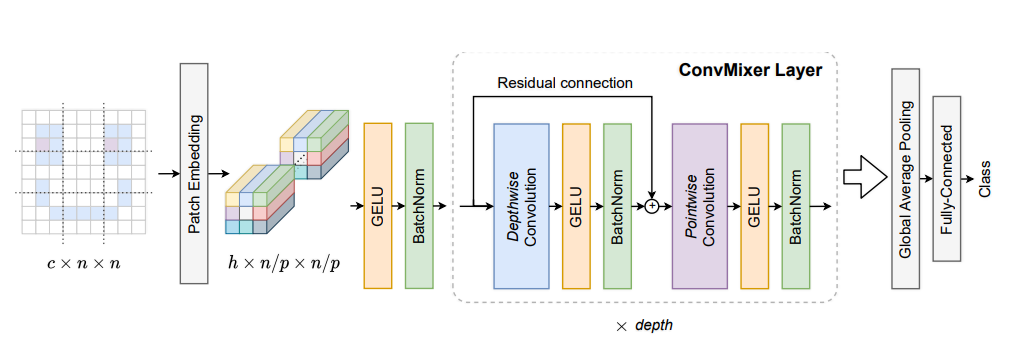

We observe that the initial layer is called *patch embedding*. This is a concept taken straight from the vision transformers [[2](#2)]; we split the images into small sub-images called *patches* (the example is from https://www.geeksforgeeks.org/deep-learning/vision-transformer-vit-architecture/).

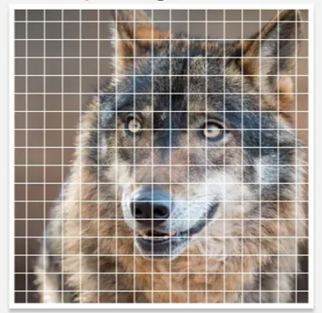

and then, we represent these sub-images by numerical vectors (*embeddings*). This may sound complicated, but in practice, patch embeddings can be implemented using a simple convolution layer with *stride = kernel_size* [[4](#4)].

Other than that, the ConvMixer architecture looks like a traditional ResNet-esque [[5](#5)] architecture with depthwise and pointwise convolutions à la MobileNet [[6](#6)]/EfficientNet [[7](#7)] and GELU activation functions instead of ReLU. Except for one striking difference: when the figure denotes that a ConvMixer layer is repeated *depth* times, it actually also means that the input sizes and the number of channels for each layer are *identical*. This contrasts with any other CNN we have covered so far, which followed a general structure of gradually decreasing image sizes, complemented by an increase in the number of channels. This design choice simplifies the architecture quite a bit (it can be homorously written in a single tweet [[1](#1)]).

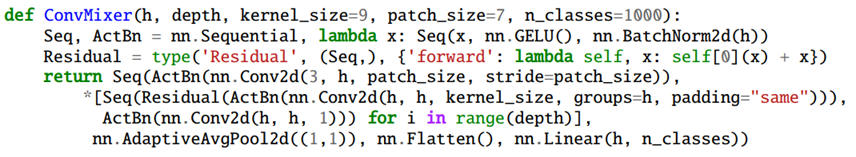

But it also follows the Vision Transformer architecture again, in which the transformer blocks follow a similar pattern.

Let us implement ConvMixer ourselves, although with a bit wordier piece of code than the one above.

In [6]:
class Residual_connection(nn.Module):
    def __init__(self, fn):
        super().__init__()
        self.fn = fn

    def forward(self, x):
        return self.fn(x) + x

In [7]:
class Depthwise_convolution(nn.Module):

    def __init__(self, num_channels, kernel_size, padding, stride):
        super().__init__()

        self.net_stack = nn.Sequential(
            nn.LazyConv2d(num_channels, kernel_size = kernel_size, stride = stride, padding = padding, groups = num_channels), 
        )
            
    def forward(self, x):
        output = self.net_stack(x)
        return output

In [8]:
class ConvMixer_block(nn.Module):

    def __init__(self, num_channels, kernel_size = 9, stride = 1, padding = 4):
        super().__init__()
    
        self.net_stack = nn.Sequential(
            Residual_connection(
                    nn.Sequential(
                    Depthwise_convolution(num_channels, kernel_size = kernel_size, stride = stride, padding = padding),
                    nn.GELU(),
                    nn.LazyBatchNorm2d()         
                )
            ),
        
        nn.LazyConv2d(num_channels, kernel_size=1),
        nn.GELU(),
        nn.LazyBatchNorm2d()
    )

    def forward(self, x):
        output = self.net_stack(x)
        return output

The default settings of ConvMixer are as follows [[1](#1)].

In [9]:
class ConvMixer(nn.Module):

    def __init__(self, num_classes, width = 1536, depth = 20, patch_size = 7, kernel_size = 9):
        super().__init__()

        convmixer_blocks = []
        for i in range(depth):
            convmixer_blocks.append(ConvMixer_block(width, kernel_size = kernel_size, stride = 1, padding = 'same'))
            
        self.net_stack = nn.Sequential(

            nn.LazyConv2d(width, kernel_size = patch_size, stride = patch_size),  nn.GELU(), nn.LazyBatchNorm2d(),
            *convmixer_blocks,
            nn.AdaptiveAvgPool2d((1,1)), 
            nn.Flatten(),
            nn.LazyLinear(num_classes)  
        )
        
    def forward(self, x):
        output = self.net_stack(x)
        return output

In [10]:
layer_summary(ConvMixer(num_classes = 10, width = 1536, depth = 20, patch_size = 7, kernel_size = 9),(1, 32, 56, 56))

Conv2d output shape:	 torch.Size([1, 1536, 8, 8])
GELU output shape:	 torch.Size([1, 1536, 8, 8])
BatchNorm2d output shape:	 torch.Size([1, 1536, 8, 8])
ConvMixer_block output shape:	 torch.Size([1, 1536, 8, 8])
ConvMixer_block output shape:	 torch.Size([1, 1536, 8, 8])
ConvMixer_block output shape:	 torch.Size([1, 1536, 8, 8])
ConvMixer_block output shape:	 torch.Size([1, 1536, 8, 8])
ConvMixer_block output shape:	 torch.Size([1, 1536, 8, 8])
ConvMixer_block output shape:	 torch.Size([1, 1536, 8, 8])
ConvMixer_block output shape:	 torch.Size([1, 1536, 8, 8])
ConvMixer_block output shape:	 torch.Size([1, 1536, 8, 8])
ConvMixer_block output shape:	 torch.Size([1, 1536, 8, 8])
ConvMixer_block output shape:	 torch.Size([1, 1536, 8, 8])
ConvMixer_block output shape:	 torch.Size([1, 1536, 8, 8])
ConvMixer_block output shape:	 torch.Size([1, 1536, 8, 8])
ConvMixer_block output shape:	 torch.Size([1, 1536, 8, 8])
ConvMixer_block output shape:	 torch.Size([1, 1536, 8, 8])
ConvMixer_block outpu

### Training ConvMixer on Fashion-MNIST and CIFAR-10 <a class="anchor" id="training"></a>

Let's train ConvMixer on Fashion-MNIST [[8](#8)] and CIFAR-10 (https://www.cs.toronto.edu/~kriz/cifar.html). Fashion-MNIST is first. We upscale the input images slightly so they make sense for the architecture.

In [11]:
torch.manual_seed(123)

# data loader
transforms_fashion_mnist_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(0.5, 0.5),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size = [56, 56], scale = [0.9,1.1]) 
    ]
)

transforms_fashion_mnist_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize([56,56]),
    torchvision.transforms.Normalize(0.5, 0.5)]
)

fashion_mnist_train = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_fashion_mnist_train)
fashion_mnist_test = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_fashion_mnist_test)

fashion_mnist_train_loader = DataLoader(dataset = fashion_mnist_train, batch_size = 150, shuffle = True) 
fashion_mnist_test_loader = DataLoader(dataset = fashion_mnist_test, batch_size = 150, shuffle = False)  


# ConvMixer initialization
ConvMixer_cuda = ConvMixer(num_classes = 10, width = 1536, depth = 20, patch_size = 7, kernel_size = 9).to(cuda_device)

x = (fashion_mnist_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
ConvMixer_cuda(x);
ConvMixer_cuda.apply(init_weights_he);

The number of parameters is noticeably higher than something like EfficientNet [[7](#7)], which starts at 5 million. 

In [12]:
sum(p.numel() for p in ConvMixer_cuda.parameters() if p.requires_grad)

49953802

In [13]:
optim_SGD_cuda =  torch.optim.SGD(ConvMixer_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[35], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

n_epochs = 50

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(fashion_mnist_train_loader, fashion_mnist_test_loader, ConvMixer_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

6394.260007619858


The training is also much slower than that of other CNNs. This is a bit of a price for no downsampling throughout the network. 

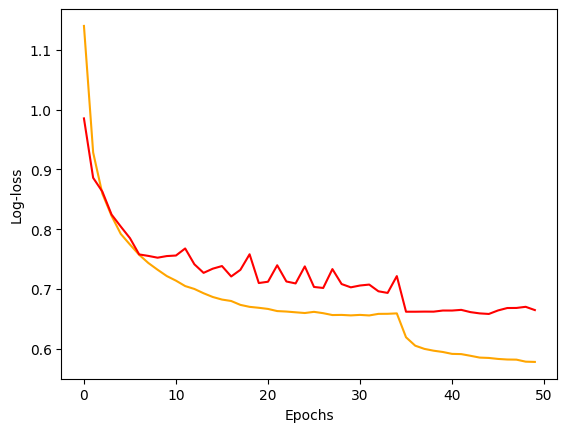

In [14]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

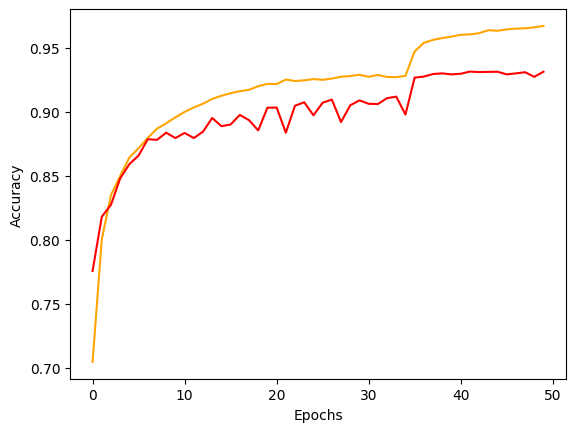

In [15]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

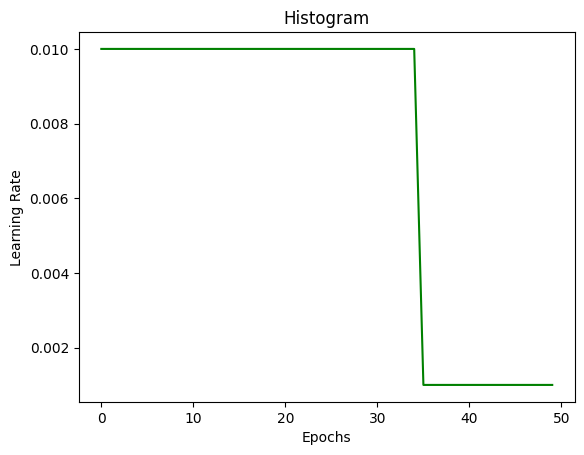

In [16]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [17]:
accu_epochs_train[49]

0.9672166705131531

In [18]:
accu_epochs_test[49]

0.9314000010490417

In [19]:
accu_epochs_test.max()

0.9314999580383301

This is slightly lower performance than the one we obtained with EfficientNet. Let us try a slightly smaller configuration inspired by experiments in [[1](#1)]. 

In [20]:
layer_summary(ConvMixer(num_classes = 10, width = 256, depth = 12, patch_size = 1, kernel_size = 9),(1, 32, 28, 28))

Conv2d output shape:	 torch.Size([1, 256, 28, 28])
GELU output shape:	 torch.Size([1, 256, 28, 28])
BatchNorm2d output shape:	 torch.Size([1, 256, 28, 28])
ConvMixer_block output shape:	 torch.Size([1, 256, 28, 28])
ConvMixer_block output shape:	 torch.Size([1, 256, 28, 28])
ConvMixer_block output shape:	 torch.Size([1, 256, 28, 28])
ConvMixer_block output shape:	 torch.Size([1, 256, 28, 28])
ConvMixer_block output shape:	 torch.Size([1, 256, 28, 28])
ConvMixer_block output shape:	 torch.Size([1, 256, 28, 28])
ConvMixer_block output shape:	 torch.Size([1, 256, 28, 28])
ConvMixer_block output shape:	 torch.Size([1, 256, 28, 28])
ConvMixer_block output shape:	 torch.Size([1, 256, 28, 28])
ConvMixer_block output shape:	 torch.Size([1, 256, 28, 28])
ConvMixer_block output shape:	 torch.Size([1, 256, 28, 28])
ConvMixer_block output shape:	 torch.Size([1, 256, 28, 28])
AdaptiveAvgPool2d output shape:	 torch.Size([1, 256, 1, 1])
Flatten output shape:	 torch.Size([1, 256])
Linear output shape:

In [21]:
torch.manual_seed(123)

# data loader
transforms_fashion_mnist_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(0.5, 0.5),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size = [28, 28], scale = [0.9,1.1]) 
    ]
)

transforms_fashion_mnist_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize([28,28]),
    torchvision.transforms.Normalize(0.5, 0.5)]
)

fashion_mnist_train = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_fashion_mnist_train)
fashion_mnist_test = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_fashion_mnist_test)

fashion_mnist_train_loader = DataLoader(dataset = fashion_mnist_train, batch_size = 75, shuffle = True) 
fashion_mnist_test_loader = DataLoader(dataset = fashion_mnist_test, batch_size = 75, shuffle = False)  


# ConvMixer initialization
ConvMixer_cuda = ConvMixer(num_classes = 10, width = 256, depth = 12, patch_size = 1, kernel_size = 9).to(cuda_device)

x = (fashion_mnist_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
ConvMixer_cuda(x);
ConvMixer_cuda.apply(init_weights_he);

In [22]:
sum(p.numel() for p in ConvMixer_cuda.parameters() if p.requires_grad)

1057290

In [23]:
optim_SGD_cuda =  torch.optim.SGD(ConvMixer_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[35], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

n_epochs = 50

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(fashion_mnist_train_loader, fashion_mnist_test_loader, ConvMixer_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

5967.7596707344055


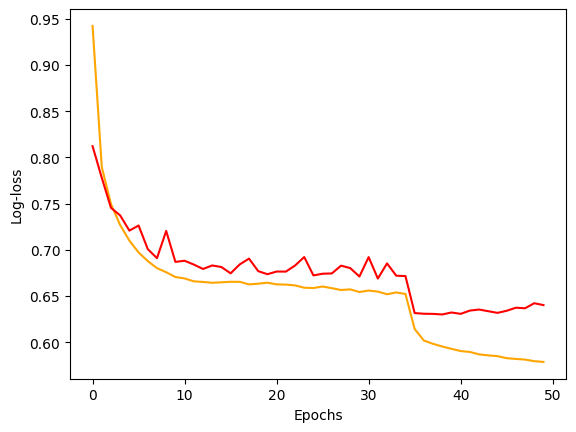

In [24]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

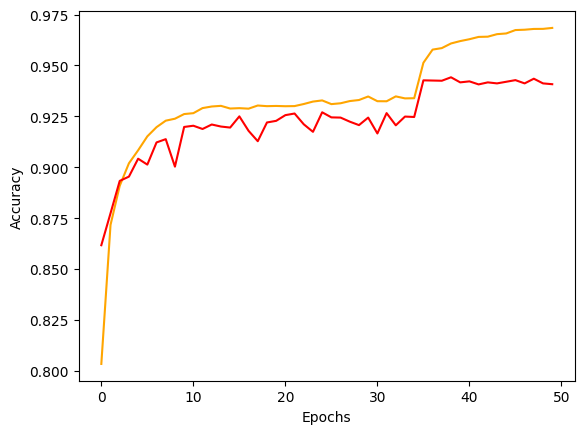

In [25]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

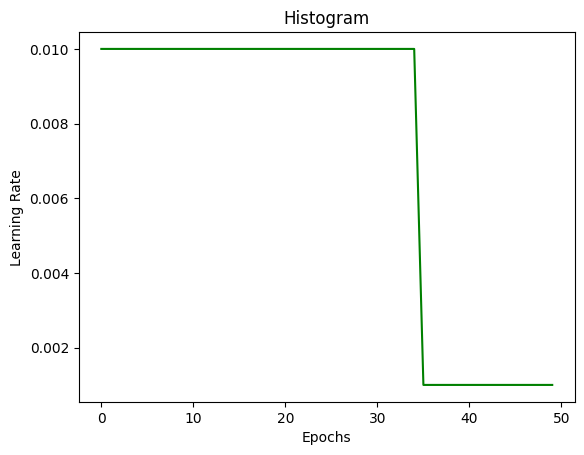

In [26]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [27]:
accu_epochs_train[49]

0.9684500098228455

In [28]:
accu_epochs_test[49]

0.9407999515533447

In [29]:
accu_epochs_test.max()

0.9441999793052673

This is much better and competitive with other CNNs we tried up to this point. CIFAR-10 is next.

In [30]:
torch.manual_seed(123)

transforms_cifar10_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616]),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size=[32,32], scale = [0.8, 1.4]),
    ]
)

transforms_cifar10_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616])]
)

cifar10_train = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_cifar10_train)
cifar10_test = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_cifar10_test)


cifar10_train_loader = DataLoader(dataset = cifar10_train, batch_size = 50, shuffle = True) 
cifar10_test_loader = DataLoader(dataset = cifar10_test, batch_size = 50, shuffle = False)

# ConvMixer initialization
ConvMixer_cuda = ConvMixer(num_classes = 10, width = 256, depth = 12, patch_size = 1, kernel_size = 9).to(cuda_device)

x = (cifar10_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
ConvMixer_cuda(x);
ConvMixer_cuda.apply(init_weights_he);

optim_SGD_cuda =  torch.optim.SGD(ConvMixer_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.001)
scheduler_cuda = torch.optim.lr_scheduler.CosineAnnealingLR(optim_SGD_cuda, 100, eta_min = 0.00001)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

n_epochs = 100

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]  = train_test_loop_cuda(cifar10_train_loader, cifar10_test_loader, ConvMixer_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

12815.634709835052


Again, we notice the slow training time.

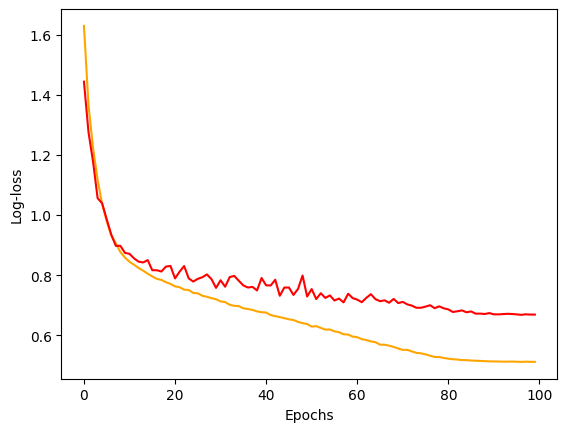

In [31]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

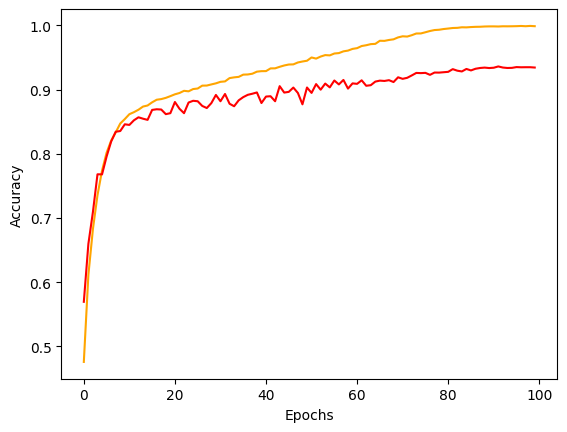

In [32]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

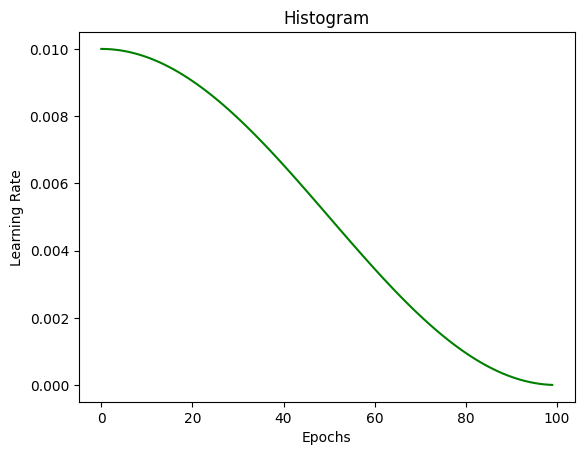

In [33]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [34]:
accu_epochs_train[99]

0.9987999796867371

In [35]:
accu_epochs_test[99]

0.9343999624252319

In [36]:
accu_epochs_test.max()

0.9361000061035156

Fine performance, but not exceptional. However, [[1](#1)] indicates that we should do much better. The biggest difference seems to be an additional image augmentation technique, *RandAugment* [[9](#9)]. It is probably not that important to go over all the details. In short, RandAugment performs random augmentations from a predetermined list, including rotation, translation, shearing, color, and contrast adjustments. The main parameters of RandAugment are how many are performed (2 in the torchvision implementation https://docs.pytorch.org/vision/main/generated/torchvision.transforms.RandAugment.html) and their magnitude.

In [37]:
torch.manual_seed(123)

transforms_cifar10_train =  torchvision.transforms.Compose(
    [
        torchvision.transforms.RandomHorizontalFlip(),
        torchvision.transforms.RandomResizedCrop(size=[32,32], scale = [0.8, 1.4]),
        torchvision.transforms.RandAugment(),
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616])
    ]
)

transforms_cifar10_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616])]
)

cifar10_train = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_cifar10_train)
cifar10_test = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_cifar10_test)


cifar10_train_loader = DataLoader(dataset = cifar10_train, batch_size = 50, shuffle = True) 
cifar10_test_loader = DataLoader(dataset = cifar10_test, batch_size = 50, shuffle = False)

# ConvMixer initialization
ConvMixer_cuda = ConvMixer(num_classes = 10, width = 256, depth = 12, patch_size = 1, kernel_size = 9).to(cuda_device)

x = (cifar10_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
ConvMixer_cuda(x);
ConvMixer_cuda.apply(init_weights_he);

optim_SGD_cuda =  torch.optim.SGD(ConvMixer_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.001)
scheduler_cuda = torch.optim.lr_scheduler.CosineAnnealingLR(optim_SGD_cuda, 100, eta_min = 0.00001)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

n_epochs = 100

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]  = train_test_loop_cuda(cifar10_train_loader, cifar10_test_loader, ConvMixer_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

12866.023668289185


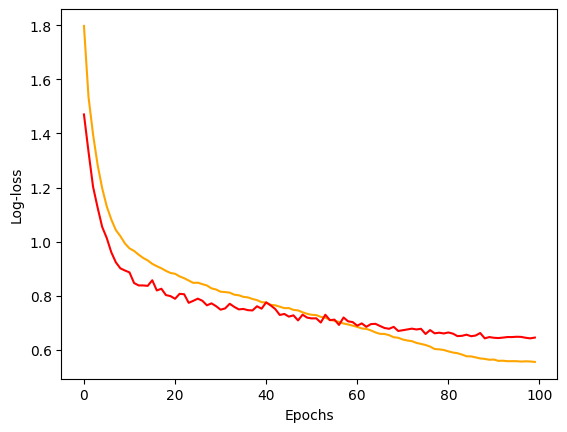

In [38]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

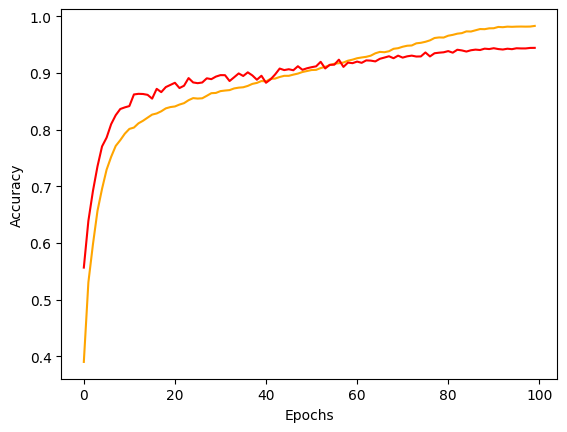

In [39]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

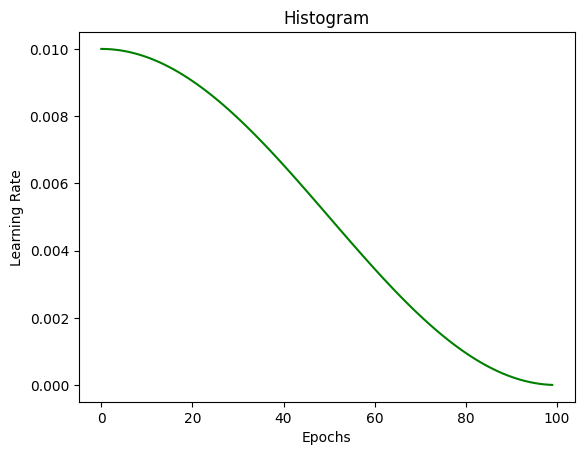

In [40]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [41]:
accu_epochs_train[99]

0.9829199910163879

In [42]:
accu_epochs_test[99]

0.9441999793052673

In [43]:
accu_epochs_test.max()

0.9441999793052673

We got an additional 1% accuracy by using RandAugment. According to [[1](#1)], we should be able to reach 95.8% after 200 epochs, which seems achievable in our setup.

### Transfer Learning ConvMixer from ImageNet to CIFAR-10 <a class="anchor" id="transfer"></a>

As the last step, let us try transfer learning from ImageNet-1K. We download ConvMixer from timm (https://huggingface.co/timm/convmixer_1536_20.in1k).

In [44]:
import timm

In [45]:
ConvMixer_cuda = timm.create_model('convmixer_1536_20.in1k', pretrained=True)

In [46]:
ConvMixer_cuda

ConvMixer(
  (stem): Sequential(
    (0): Conv2d(3, 1536, kernel_size=(7, 7), stride=(7, 7))
    (1): GELU(approximate='none')
    (2): BatchNorm2d(1536, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): Residual(
        (fn): Sequential(
          (0): Conv2d(1536, 1536, kernel_size=(9, 9), stride=(1, 1), padding=same, groups=1536)
          (1): GELU(approximate='none')
          (2): BatchNorm2d(1536, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
      )
      (1): Conv2d(1536, 1536, kernel_size=(1, 1), stride=(1, 1))
      (2): GELU(approximate='none')
      (3): BatchNorm2d(1536, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): Sequential(
      (0): Residual(
        (fn): Sequential(
          (0): Conv2d(1536, 1536, kernel_size=(9, 9), stride=(1, 1), padding=same, groups=1536)
          (1): GELU(approximate='none')
          (2): BatchNorm2d(1536

As with other CNNs, we replace the classification layer and freeze the convolution layers, but keep the batch normalization available for training. 

In [47]:
for param in ConvMixer_cuda.parameters():
    param.requires_grad = False

In [48]:
for m in ConvMixer_cuda.modules():
    if isinstance(m, nn.BatchNorm2d):
        m.weight.requires_grad_(True)
        m.bias.requires_grad_(True)

In [49]:
ConvMixer_cuda.head_drop = nn.Dropout(0.2)

In [50]:
ConvMixer_cuda.head = nn.Linear(1536,10)

In [51]:
ConvMixer_cuda = ConvMixer_cuda.to(cuda_device)

In [52]:
def fine_tune_test_loop_cuda(train_data_loader, test_data_loader, model, loss_fn, optimizer, scheduler):
    
    softmax = torch.nn.Softmax(dim = 1)
    model.train()

    for m in model.modules():
        if isinstance(m, nn.BatchNorm2d):
            m.eval()
            
    loss_sum_train  = 0
    accu_sum_train = 0
    size_train = 0

    
    for batch, (X, y) in enumerate(train_data_loader):

        X = X.to(cuda_device)
        y = y.to(cuda_device)

        optimizer.zero_grad() # zero out the gradients
        
        pred_logits = model(X) # forward pass
        loss = loss_fn(pred_logits, y) # loss evaluation 

        # Backpropagation
        loss.backward() # gradient evaluation
        optimizer.step() # SGD step
        

        # compute prediction epoch loss and accuracy
        with torch.no_grad(): # we do not need to compute the gradients
            loss_sum_train = loss_sum_train + loss*len(X)
            size_train = size_train + len(X)
            accu_sum_train = accu_sum_train + ((softmax(pred_logits).argmax(dim = 1)-y).abs() == 0).long().sum()

    # evaluate performance on the test set
    with torch.no_grad(): 
        
        loss_sum_train = loss_sum_train/size_train
        accu_sum_train = accu_sum_train/size_train
        
        model.eval() 
        loss_sum_test  = 0
        accu_sum_test = 0
        size_test = 0
        
        for batch, (X_test, y_test) in enumerate(test_data_loader):

            X_test = X_test.to(cuda_device)
            y_test = y_test.to(cuda_device)
            
            pred_logits_test = model(X_test)
            loss_sum_test = loss_sum_test + loss_fn(pred_logits_test, y_test)*len(X_test)
            accu_sum_test = accu_sum_test + ((softmax(pred_logits_test).argmax(dim = 1)-y_test).abs() == 0).long().sum()
            size_test = size_test + len(X_test)

        loss_sum_test = loss_sum_test/size_test
        accu_sum_test = accu_sum_test/size_test
        
    # learning rate step; we use loss_sum_train for ReduceLROnPlateau
    learning_rate = scheduler.get_last_lr() 
    scheduler.step() 
    
    return  loss_sum_train.detach(), loss_sum_test.detach(), learning_rate[0], accu_sum_train.detach(), accu_sum_test.detach()

The transformer-like architecture strikes again: we have to use a *very small* batch size of 8 to fit the training into our 14GB of VRAM.

In [53]:
torch.manual_seed(123)

transforms_cifar10_train =  torchvision.transforms.Compose(
    [
        torchvision.transforms.RandomHorizontalFlip(),
        torchvision.transforms.RandomResizedCrop(size=[224,224], scale = [0.8, 1.4]),
        torchvision.transforms.RandAugment(),
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616])
    ]
)

transforms_cifar10_test =  torchvision.transforms.Compose(
    [
        torchvision.transforms.Resize([224,224]),
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616])
    ]
)


cifar10_train = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_cifar10_train)
cifar10_test = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_cifar10_test)

cifar10_train_loader = DataLoader(dataset = cifar10_train, batch_size = 8, shuffle = True) 
cifar10_test_loader = DataLoader(dataset = cifar10_test, batch_size = 8, shuffle = False)

In [54]:
n_epochs = 10

optim_SGD_cuda =  torch.optim.SGD(ConvMixer_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[-1], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = fine_tune_test_loop_cuda(cifar10_train_loader, cifar10_test_loader, ConvMixer_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

11100.121295928955


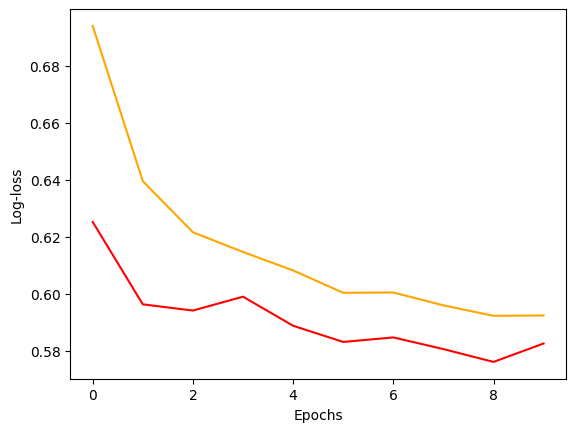

In [55]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

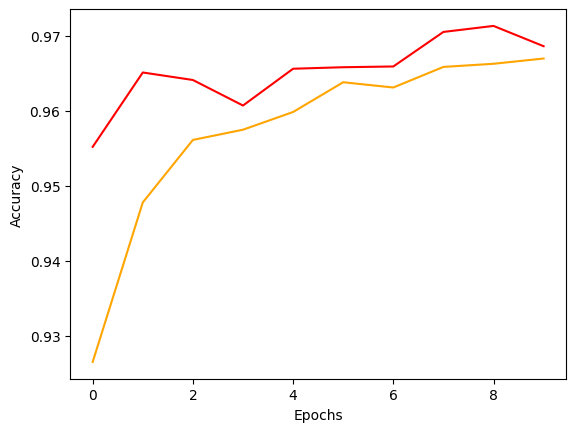

In [56]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

In [57]:
accu_epochs_test.max()

0.971299946308136

This is a better result than the one we got with EfficientNet, but not better than EfficientNet-V2, though [[10](#10)]. 

## References <a class="anchor" id="references"></a>

<a id="1">[1]</a> TROCKMAN, Asher; KOLTER, J. Zico. Patches are all you need?. *arXiv preprint arXiv:2201.09792*, 2022.

<a id="2">[2]</a> DOSOVITSKIY, Alexey, et al. An image is worth 16x16 words: Transformers for image recognition at scale. arXiv preprint arXiv:2010.11929, 2020.

<a id="3">[3]</a> VASWANI, Ashish, et al. Attention is all you need. *Advances in neural information processing systems*, 2017, 30.

<a id="4">[4]</a> ZHANG, Aston, et al. *Dive into deep learning*. Cambridge University Press, 2023.

<a id="5">[5]</a> HE, Kaiming, et al. Deep residual learning for image recognition. In: Proceedings of the IEEE conference on computer vision and pattern recognition. 2016. p. 770-778.

<a id="6">[6]</a> SANDLER, Mark, et al. MobileNetv2: Inverted residuals and linear bottlenecks. In: *Proceedings of the IEEE conference on computer vision and pattern recognition.* 2018. p. 4510-4520.

<a id="7">[7]</a> TAN, Mingxing; LE, Quoc. EfficientNet: Rethinking model scaling for convolutional neural networks. In: *International conference on machine learning. PMLR, 2019.* p. 6105-6114.

<a id="8">[8]</a> XIAO, Han; RASUL, Kashif; VOLLGRAF, Roland. Fashion-mnist: a novel image dataset for benchmarking machine learning algorithms. *arXiv preprint arXiv:1708.07747,* 2017.

<a id="9">[9]</a> CUBUK, Ekin D., et al. Randaugment: Practical automated data augmentation with a reduced search space. In: Proceedings of the IEEE/CVF conference on computer vision and pattern recognition workshops. 2020. p. 702-703.

<a id="10">[10]</a> TAN, Mingxing; LE, Quoc. EfficientNetv2: Smaller models and faster training. In: *International conference on machine learning. PMLR, 2021.* p. 10096-10106.